<a href="https://colab.research.google.com/github/isobhit/imdb-assignment/blob/main/IMDB_ASSIGNMENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##<b> INTRODUCTION TO DATA SCIENCE - ASSIGNMENT 2
</b>


##<b>You have been hired by a rookie movie producer to help him decide what type of movies to produce and which actors to cast. You have to back your recommendations based on thorough analysis of the data he shared with you which has the list of 3000 movies and the corresponding details.</b>

<br>


## <b> As a data scientist, you have to first explore the data and check its sanity.</b>

<br>

## <u><b>Further, you have to answer the following questions:</b></u>
### 1. Which movie made the highest profit? Who were its producer and director? Identify the actors in that film.
### 2. This data has information about movies made in different languages. Which language has the highest average ROI (return on investment)?
### 3. Find out the unique genres of movies in this dataset.
### 4. Make a table of all the producers and directors of each movie. Find the top 3 producers who have produced movies with the highest average ROI?
### 5. Which actor has acted in the most number of movies? Deep dive into the movies, genres and profits corresponding to this actor.
### 6. Top 3 directors prefer which actors the most?




In [1]:
import pandas as pd
import ast
import numpy as np

In [6]:
df = pd.read_csv('imdb_data (1).csv')

## <u><b>EXPLORING THE DATA & SANITY CHECKS</b></u>




In [7]:
print("--- First 3 rows of the dataset ---")
display(df.head(3))

--- First 3 rows of the dataset ---


,id,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,...,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,crew,revenue
0,1,"[{'id': 313576, 'name': 'Hot Tub Time Machine ...",14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,tt2637294,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,...,2/20/15,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...","[{'cast_id': 4, 'character': 'Lou', 'credit_id...","[{'credit_id': '59ac067c92514107af02c8c8', 'de...",12314651
1,2,"[{'id': 107674, 'name': 'The Princess Diaries ...",40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,tt0368933,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,...,8/6/04,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It can take a lifetime to find true love; she'...,The Princess Diaries 2: Royal Engagement,"[{'id': 2505, 'name': 'coronation'}, {'id': 42...","[{'cast_id': 1, 'character': 'Mia Thermopolis'...","[{'credit_id': '52fe43fe9251416c7502563d', 'de...",95149435
2,3,NaN,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,tt2582802,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,...,10/10/14,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The road to greatness can take you to the edge.,Whiplash,"[{'id': 1416, 'name': 'jazz'}, {'id': 1523, 'n...","[{'cast_id': 5, 'character': 'Andrew Neimann',...","[{'credit_id': '54d5356ec3a3683ba0000039', 'de...",13092000


In [8]:
print("\n--- Data Information (Rows, Columns, Data Types) ---")
df.info()


--- Data Information (Rows, Columns, Data Types) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     3000 non-null   int64  
 1   belongs_to_collection  604 non-null    object 
 2   budget                 3000 non-null   int64  
 3   genres                 2993 non-null   object 
 4   homepage               946 non-null    object 
 5   imdb_id                3000 non-null   object 
 6   original_language      3000 non-null   object 
 7   original_title         3000 non-null   object 
 8   overview               2992 non-null   object 
 9   popularity             3000 non-null   float64
 10  poster_path            2999 non-null   object 
 11  production_companies   2844 non-null   object 
 12  production_countries   2945 non-null   object 
 13  release_date           3000 non-null   object 
 14  ru

In [9]:
print("\n--- Checking for Missing Values ---")
print(df.isnull().sum())


--- Checking for Missing Values ---
id                          0
belongs_to_collection    2396
budget                      0
genres                      7
homepage                 2054
imdb_id                     0
original_language           0
original_title              0
overview                    8
popularity                  0
poster_path                 1
production_companies      156
production_countries       55
release_date                0
runtime                     2
spoken_languages           20
status                      0
tagline                   597
title                       0
Keywords                  276
cast                       13
crew                       16
revenue                     0
dtype: int64


In [10]:
print("\n--- Basic Statistics of Numerical Columns ---")
display(df.describe())


--- Basic Statistics of Numerical Columns ---


,id,budget,popularity,runtime,revenue
count,3000.000000,3.000000e+03,3000.000000,2998.000000,3.000000e+03
mean,1500.500000,2.253133e+07,8.463274,107.856571,6.672585e+07
std,866.169729,3.702609e+07,12.104000,22.086434,1.375323e+08
min,1.000000,0.000000e+00,0.000001,0.000000,1.000000e+00
25%,750.750000,0.000000e+00,4.018053,94.000000,2.379808e+06
50%,1500.500000,8.000000e+06,7.374861,104.000000,1.680707e+07
75%,2250.250000,2.900000e+07,10.890983,118.000000,6.891920e+07
max,3000.000000,3.800000e+08,294.337037,338.000000,1.519558e+09


## <u><b>Data Cleaning & Preparation</b></u>




In [11]:
def extract_names(item_string):
    try:
        items = ast.literal_eval(item_string)

        return [i['name'] for i in items]
    except:
        return []

def extract_director(crew_string):
    try:
        crew = ast.literal_eval(crew_string)
        for person in crew:
            if person['job'] == 'Director':
                return person['name']
        return "Unknown"
    except:
        return "Unknown"

def extract_producers(crew_string):
    try:
        crew = ast.literal_eval(crew_string)
        producers = []
        for person in crew:
            if person['job'] == 'Producer':
                producers.append(person['name'])
        return producers
    except:
        return []

df['clean_genres'] = df['genres'].apply(extract_names)
df['clean_cast'] = df['cast'].apply(extract_names)
df['director'] = df['crew'].apply(extract_director)
df['producers'] = df['crew'].apply(extract_producers)

df['profit'] = df['revenue'] - df['budget']

df['ROI'] = np.where(df['budget'] > 0, df['profit'] / df['budget'], 0)

print("Data cleaning and calculations complete! We now have profit, ROI, and clean names.")

Data cleaning and calculations complete! We now have profit, ROI, and clean names.


## <u><b>QUESTIONS :</b></u>




### 1. Which movie made the highest profit? Who were its producer and director? Identify the actors in that film.



In [12]:
highest_profit_idx = df['profit'].idxmax()

top_movie = df.loc[highest_profit_idx]

print(f"1. Movie with the Highest Profit: {top_movie['title']}")
print(f"Profit Made: ${top_movie['profit']:,.2f}")
print(f"Director: {top_movie['director']}")
print(f"Producer(s): {', '.join(top_movie['producers'])}")

print(f"Top Cast: {', '.join(top_movie['clean_cast'][:5])}")

1. Movie with the Highest Profit: Furious 7
Profit Made: $1,316,249,360.00
Director: James Wan
Producer(s): Vin Diesel, Neal H. Moritz, Michael Fottrell, Brandon Birtell
Top Cast: Vin Diesel, Paul Walker, Dwayne Johnson, Michelle Rodriguez, Tyrese Gibson


### 2. This data has information about movies made in different languages. Which language has the highest average ROI (return on investment)?



In [13]:
valid_budget_df = df[df['budget'] > 0]

top_language_roi = valid_budget_df.groupby('original_language')['ROI'].mean().sort_values(ascending=False)

print("2. Language with the highest average ROI:")
print(f"Language Code: '{top_language_roi.index[0]}'")
print(f"Average ROI: {top_language_roi.iloc[0]:.2f}")

2. Language with the highest average ROI:
Language Code: 'ko'
Average ROI: 381794.10


### 3. Find out the unique genres of movies in this dataset.



In [14]:
unique_genres = set()

for genres_list in df['clean_genres']:
    for genre in genres_list:
        unique_genres.add(genre)

print(f"3. There are {len(unique_genres)} unique genres in this dataset:")
print(list(unique_genres))

3. There are 20 unique genres in this dataset:
['Thriller', 'Romance', 'Documentary', 'Music', 'War', 'Drama', 'Family', 'Crime', 'TV Movie', 'Animation', 'Western', 'Foreign', 'Horror', 'Action', 'Science Fiction', 'Mystery', 'Fantasy', 'History', 'Comedy', 'Adventure']


### 4. Make a table of all the producers and directors of each movie. Find the top 3 producers who have produced movies with the highest average ROI?

In [15]:
producer_director_table = df[['title', 'director', 'producers']]
print("--- Table of Producers and Directors (First 5 Rows) ---")
display(producer_director_table.head())

exploded_producers = df[['producers', 'ROI']].explode('producers')

exploded_producers = exploded_producers.dropna(subset=['producers'])

top_3_producers = exploded_producers.groupby('producers')['ROI'].mean().sort_values(ascending=False).head(3)

print("\n--- Top 3 Producers by Average ROI ---")
print(top_3_producers)

--- Table of Producers and Directors (First 5 Rows) ---


,title,director,producers
0,Hot Tub Time Machine 2,Steve Pink,[Andrew Panay]
1,The Princess Diaries 2: Royal Engagement,Garry Marshall,"[Whitney Houston, Mario Iscovich, Debra Martin..."
2,Whiplash,Damien Chazelle,"[David Lancaster, Michel Litvak, Jason Blum, H..."
3,Kahaani,Sujoy Ghosh,[Sujoy Ghosh]
4,Marine Boy,Jong-seok Yoon,[]



--- Top 3 Producers by Average ROI ---
producers
Jang Jin        4197475.625
Lee Eun-ha      4197475.625
Ji Sang-yong    4197475.625
Name: ROI, dtype: float64


### 5. Which actor has acted in the most number of movies? Deep dive into the movies, genres and profits corresponding to this actor.

In [16]:
exploded_cast = df[['title', 'clean_cast', 'clean_genres', 'profit']].explode('clean_cast')

top_actor = exploded_cast['clean_cast'].value_counts().idxmax()
top_actor_count = exploded_cast['clean_cast'].value_counts().max()

print(f"5. The actor in the most movies is: {top_actor} ({top_actor_count} movies)")

actor_movies = exploded_cast[exploded_cast['clean_cast'] == top_actor]

print(f"\n--- Deep Dive into {top_actor}'s Movies ---")
display(actor_movies[['title', 'clean_genres', 'profit']])

print(f"\nAverage Profit for {top_actor}'s movies: ${actor_movies['profit'].mean():,.2f}")

5. The actor in the most movies is: Samuel L. Jackson (30 movies)

--- Deep Dive into Samuel L. Jackson's Movies ---


,title,clean_genres,profit
29,Changing Lanes,"[Action, Adventure, Crime, Thriller]",49935764
47,The Hateful Eight,"[Crime, Drama, Mystery, Western]",111760117
642,Coming to America,"[Comedy, Romance]",249752301
689,Star Wars: Episode III - Revenge of the Sith,"[Science Fiction, Adventure, Action]",737000000
1055,Meeting Evil,"[Crime, Drama, Mystery, Thriller]",525
1126,The Avengers,"[Science Fiction, Action, Adventure]",1299557910
1181,Jumper,"[Adventure, Fantasy, Science Fiction]",137231186
1426,Shaft,"[Action, Adventure, Crime, Thriller]",61196498
1482,Snakes on a Plane,"[Action, Crime, Horror, Thriller]",29022014
1585,The Man,"[Action, Comedy, Crime]",12382362



Average Profit for Samuel L. Jackson's movies: $226,510,055.67


### 6. Top 3 directors prefer which actors the most?

In [17]:
top_3_directors = df[df['director'] != 'Unknown']['director'].value_counts().head(3).index.tolist()

print("6. Top 3 Directors and their preferred actors:")

for director in top_3_directors:
    director_movies = df[df['director'] == director]

    director_cast_exploded = director_movies.explode('clean_cast')

    if not director_cast_exploded['clean_cast'].empty:
        preferred_actor = director_cast_exploded['clean_cast'].value_counts().idxmax()
        appearances = director_cast_exploded['clean_cast'].value_counts().max()
        print(f"Director: {director} | Most Preferred Actor: {preferred_actor} ({appearances} movies together)")

6. Top 3 Directors and their preferred actors:
Director: Clint Eastwood | Most Preferred Actor: Clint Eastwood (8 movies together)
Director: Ron Howard | Most Preferred Actor: Clint Howard (7 movies together)
Director: Steven Spielberg | Most Preferred Actor: Harrison Ford (3 movies together)


## <u><b>DATA VISUALIZATION :</b></u>




### 1. Top 10 Genres (Bar Chart)

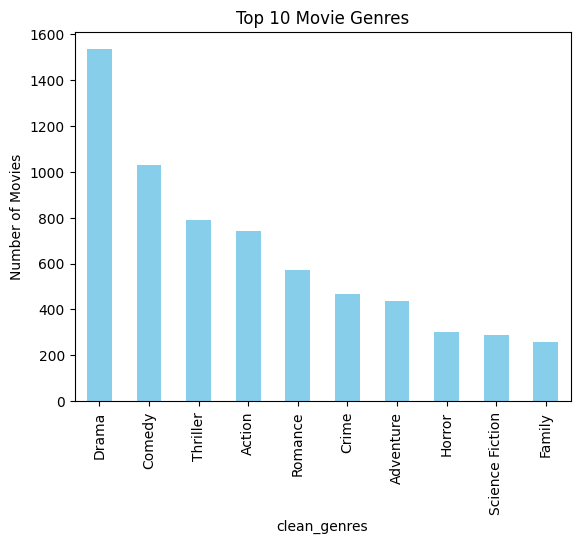

In [18]:
import matplotlib.pyplot as plt

df['clean_genres'].explode().value_counts().head(10).plot(kind='bar', title='Top 10 Movie Genres', color='skyblue')
plt.ylabel('Number of Movies')
plt.show()

### 2. Budget vs. Revenue (Scatter Plot)

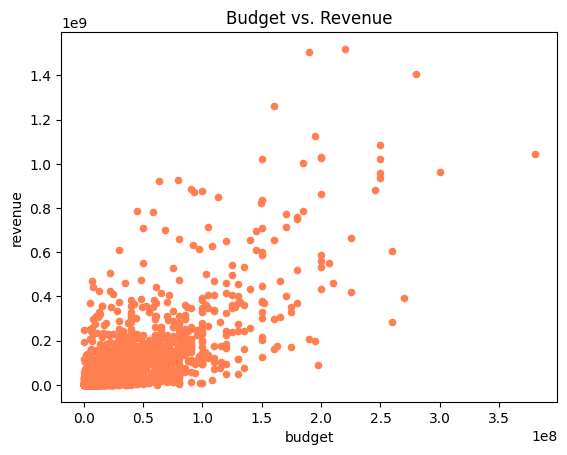

In [19]:
df[(df['budget'] > 0) & (df['revenue'] > 0)].plot.scatter(x='budget', y='revenue', title='Budget vs. Revenue', color='coral')
plt.show()

### 3. Top 5 Languages by ROI (Bar Chart)

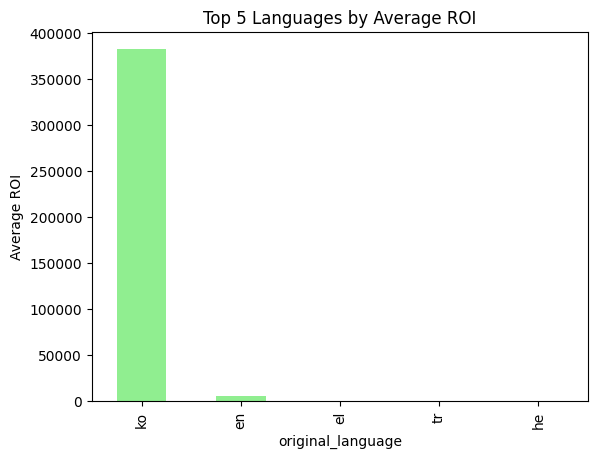

In [20]:
df[df['budget'] > 0].groupby('original_language')['ROI'].mean().nlargest(5).plot(kind='bar', title='Top 5 Languages by Average ROI', color='lightgreen')
plt.ylabel('Average ROI')
plt.show()